In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [2]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [3]:
image, label = train_data[1]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
           0.0000, 0.0000, 0.1608, 0.7373, 0.4039, 0.2118, 0.1882, 0.1686,
           0.3412, 0.6588, 0.5216, 0.0627, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.1922,
           0.5333, 0.8588, 0.8471, 0.8941, 0.9255, 1.0000, 1.0000, 1.0000,
           1.0000, 0.8510, 0.8431, 0.9961, 0.9059, 0.6275, 0.1765, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0549, 0.6902, 0.8706,
           0.8784, 0.8314, 0.7961, 0.7765, 0.7686, 0.7843, 0.8431, 0.8000,
           0.7922, 0.7882, 0.7882, 0.7882, 0.8196, 0.8549, 0.8784, 0.6431,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7373, 0.8588, 0.7843,
           0.7765, 0.7922, 0.7765, 0.7804, 0.7804, 0.7882, 0.7686, 0.7765,
           0.7765, 0.7843, 0.7843, 0.7843, 

In [4]:
image.shape

torch.Size([1, 28, 28])

In [5]:
len(train_data.data) , len(train_data.targets) , len(test_data.data) , len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
classes=train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, '0')

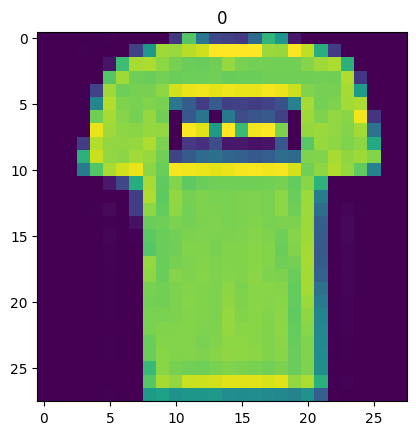

In [7]:
plt.imshow(image.squeeze())
plt.title(label)

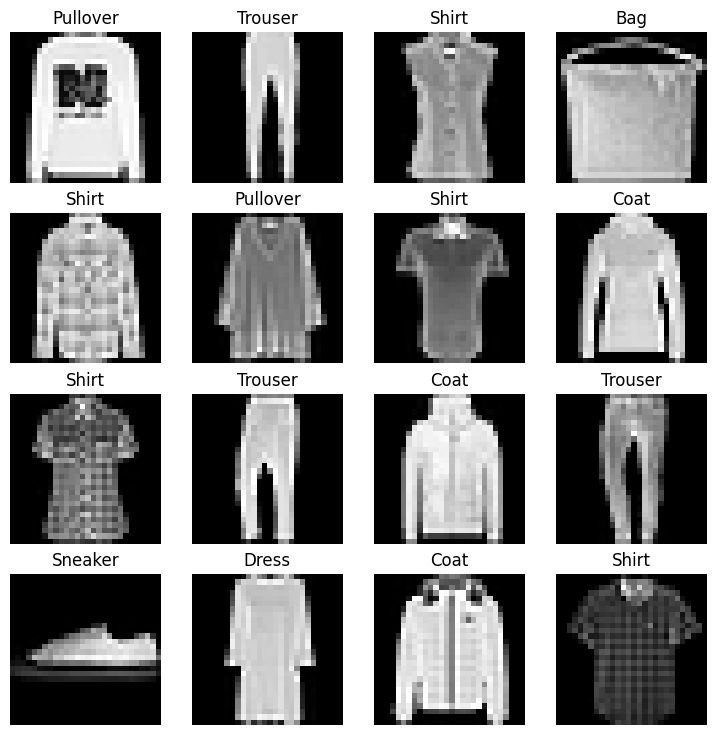

In [8]:
torch.manual_seed(7)
fig=plt.figure(figsize=(9,9))
rows, cols=4,4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label=train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[label])
    plt.axis(False);

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE=32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
len(train_dataloader) , len(test_dataloader)

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000023742276900>, <torch.utils.data.dataloader.DataLoader object at 0x0000023743672990>)


(1875, 313)

In [10]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape  ,  train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [11]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)

print(x.shape , output.shape)

torch.Size([1, 28, 28]) torch.Size([1, 784])


In [12]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)    

In [13]:
torch.manual_seed(77)

model_0 = FashionMNISTModelV0(784, 10, len(classes))
model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
from torchmetrics import Accuracy
acc = Accuracy(task='multiclass',num_classes=len(classes))

In [15]:
from timeit import default_timer as Timer
def print_train_time(start: float, end: float, device: torch.device=None):
    total_time = end-start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [16]:
!pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(77)
train_time_start_on_cpu = Timer()
epochs = 3

for epoch in range(epochs):
    print(f"Epoch: {epoch}\n--------")
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch *  len(X)}/{len(train_dataloader.dataset)} samples")
        
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
            test_loss = loss_fn(test_pred, y)
            test_acc += acc(y, test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.5f}")    
train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(train_time_start_on_cpu, train_time_end_on_cpu,
                            device=str(next(model_0.parameters()).device)) 

Epoch: 0
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47482 | Test loss: 0.00106 | Test acc: 0.82877
Epoch: 1
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45492 | Test loss: 0.00118 | Test acc: 0.83397
Epoch: 2
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.44329 | Test loss: 0.00105 | Test acc: 0.83267
Train time on cpu: 21.178 seconds


In [22]:
torch.manual_seed(77)
def eval_model_fn(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
                  loss_func: torch.nn.Module, accuracy_fn: Accuracy):
    loss, accr = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)

            loss += loss_func(y_pred,y)
            accr += accuracy_fn(y_pred,y)

        loss /= len(data_loader)
        accr /= len(data_loader)
    return {"model_name": model.__class__.__name__, "model_loss":loss.item(),
            "model_acc":accr}

model_0_results = eval_model_fn(model_0, test_dataloader, loss_fn, acc)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4706506133079529,
 'model_acc': tensor(0.8327)}

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, inputs_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=inputs_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

torch.manual_seed(77)
model_1 = FashionMNISTModelV1(784, 10, len(classes)).to(device)
next(model_1.parameters())

Parameter containing:
tensor([[-0.0149, -0.0153, -0.0070,  ..., -0.0225,  0.0006,  0.0004],
        [-0.0282, -0.0029, -0.0238,  ..., -0.0201,  0.0008, -0.0255],
        [ 0.0251,  0.0175, -0.0147,  ...,  0.0198, -0.0153, -0.0212],
        ...,
        [-0.0247,  0.0103, -0.0245,  ..., -0.0057, -0.0187,  0.0013],
        [-0.0075, -0.0130,  0.0121,  ..., -0.0108,  0.0265, -0.0253],
        [ 0.0030, -0.0229,  0.0121,  ...,  0.0226, -0.0004,  0.0108]],
       device='cuda:0', requires_grad=True)

In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
acc = Accuracy(task="multiclass", num_classes=len(classes))